#### Load & Inspect the Dataset

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('youth_unemployment_global.csv')
df.head() 

,Country,CountryCode,Year,YouthUnemployment
0,Africa Eastern and Southern,ZH,2024,13.283002
1,Africa Eastern and Southern,ZH,2023,13.367810
2,Africa Eastern and Southern,ZH,2022,13.620217
3,Africa Eastern and Southern,ZH,2021,14.955182
4,Africa Eastern and Southern,ZH,2020,14.997030


#### Data Basic Information


In [ ]:
df.shape

In [ ]:
df.columns

In [ ]:
df.info()


### Clean & Filter dataset

In [ ]:

df_clean = df.dropna(subset=['YouthUnemployment'])
df_modern = df_clean[df_clean['Year'] >= 1991]
latest_year = df_modern['Year'].max()
top_10_2024 = df_modern[df_modern['Year'] == latest_year].sort_values('YouthUnemployment', ascending=False).head(10)

print(f"Data cleaned. Analyzing {len(df_modern)} records from 1991 to {latest_year}.")

Data cleaned. Analyzing 7981 records from 1991 to 2024.


#### Summary Statistics Table


In [ ]:

summary_table = df_modern.groupby('Year')['YouthUnemployment'].agg(['mean', 'min', 'max']).tail(5)

summary_table = summary_table.round(2)
summary_table.columns = ['Avg Unemployment (%)', 'Min Rate (%)', 'Max Rate (%)']
summary_table.to_csv('summary_statistics_table.csv')

summary_table

,Avg Unemployment (%),Min Rate (%),Max Rate (%)
Year,,,
2020,18.58,0.47,82.41
2021,17.55,0.69,79.68
2022,15.90,0.41,76.31
2023,15.39,0.42,76.27
2024,15.31,0.30,76.32


#### VISUALISATIONS


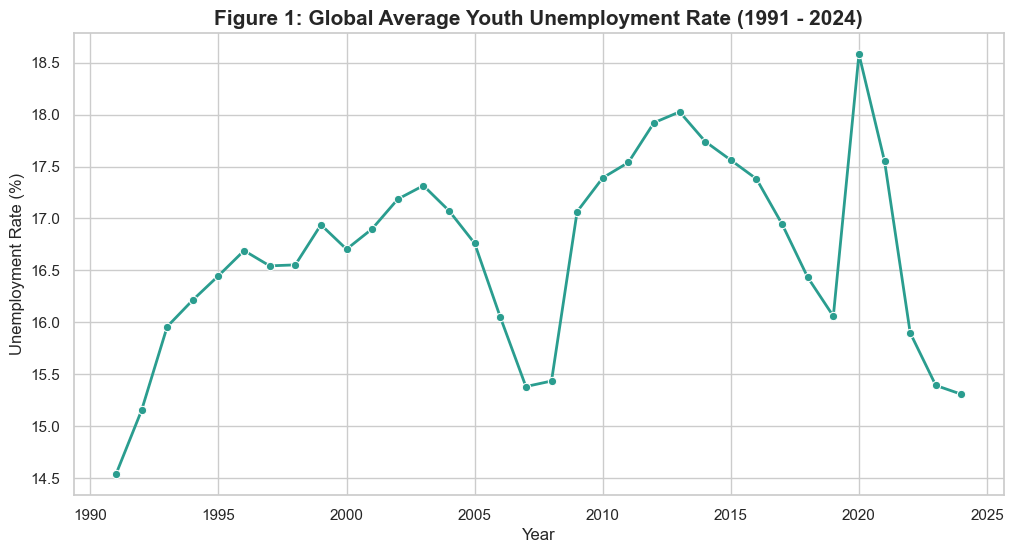

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
global_trend = df_modern.groupby('Year')['YouthUnemployment'].mean().reset_index()
sns.lineplot(data=global_trend, x='Year', y='YouthUnemployment', marker='o', color='#2a9d8f', linewidth=2)
plt.title('Figure 1: Global Average Youth Unemployment Rate (1991 - 2024)', fontsize=15, fontweight='bold')
plt.ylabel('Unemployment Rate (%)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.savefig('figure_1_trend.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11524\4213689251.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_2024, x='YouthUnemployment', y='Country', palette='flare')


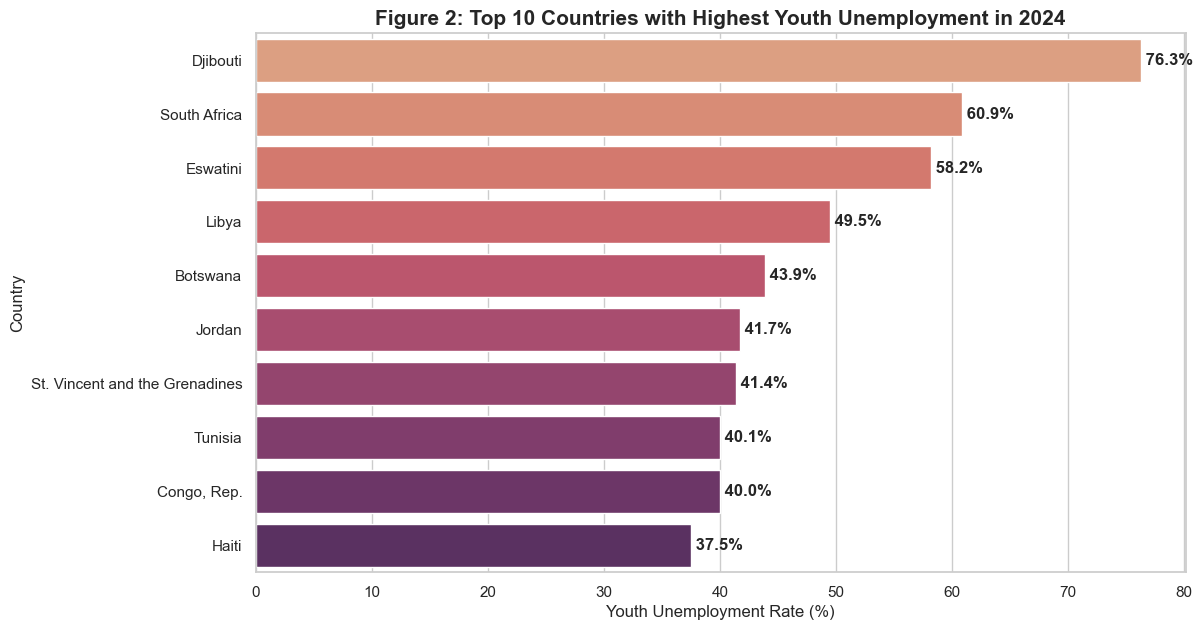

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(data=top_10_2024, x='YouthUnemployment', y='Country', palette='flare')
for index, value in enumerate(top_10_2024['YouthUnemployment']):
    plt.text(value, index, f' {value:.1f}%', va='center', fontweight='bold')
plt.title('Figure 2: Top 10 Countries with Highest Youth Unemployment in 2024', fontsize=15, fontweight='bold')
plt.xlabel('Youth Unemployment Rate (%)', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.savefig('figure_2_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11524\1741230091.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_comp, x='Year', y='YouthUnemployment', palette='Pastel1', width=0.4)


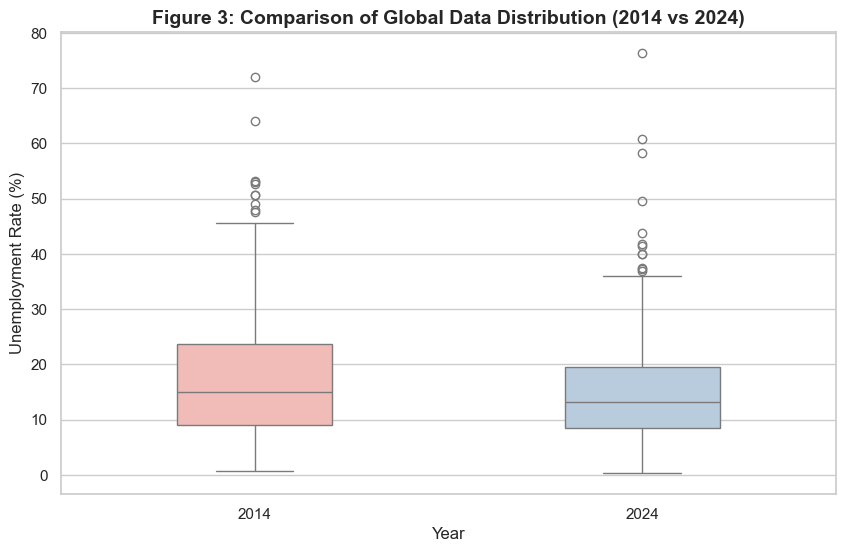

In [ ]:
plt.figure(figsize=(10, 6))
df_comp = df_clean[df_clean['Year'].isin([2014, 2024])]
sns.boxplot(data=df_comp, x='Year', y='YouthUnemployment', palette='Pastel1', width=0.4)
plt.title('Figure 3: Comparison of Global Data Distribution (2014 vs 2024)', fontsize=14, fontweight='bold')
plt.ylabel('Unemployment Rate (%)')
plt.savefig('plot_3_distribution.png', bbox_inches='tight')
plt.show()